In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
from copy import deepcopy

from src.states.state_simulator import StateSimulator

from src.simulation.environment import (
    DeFiEnvironment
)

from src.simulation.monte_carlo import (
    MonteCarloEngine
)

from src.portfolio.allocation_policies import (

    CarryMaximizerPolicy,

    RegimeAdaptivePolicy,

    RobustGrowthPolicy,
)
from src.risk.drawdown import (
    compute_max_drawdown
)
from src.states.regime import REGIME_TO_INDEX



from src.risk.metrics import (
    compute_cagr,
    compute_log_growth
)

In [3]:
base_transition_matrix = np.array([

    [0.92, 0.08, 0.00, 0.00],

    [0.03, 0.92, 0.05, 0.00],

    [0.00, 0.08, 0.88, 0.04],

    [0.00, 0.00, 0.18, 0.82],
])


In [4]:
from src.states.regime import REGIME_TO_INDEX


def perturb_panic_probability(
    base_matrix,
    scale
):

    matrix = base_matrix.copy()

    STRESS = REGIME_TO_INDEX["stress"]

    PANIC = REGIME_TO_INDEX["panic"]

    STABLE = REGIME_TO_INDEX["stable_range"]


    # --------------------------------------------------
    # Increase stress -> panic transitions
    # --------------------------------------------------

    matrix[STRESS, PANIC] *= scale


    # --------------------------------------------------
    # Increase panic persistence
    # --------------------------------------------------

    matrix[PANIC, PANIC] *= scale


    # --------------------------------------------------
    # Reduce escape from panic
    # --------------------------------------------------

    matrix[PANIC, STABLE] *= 1 / scale


    # --------------------------------------------------
    # Row normalization
    # --------------------------------------------------

    matrix = (
        matrix
        / matrix.sum(axis=1, keepdims=True)
    )

    return matrix

In [5]:
from src.risk.risk_engine import RiskEngine
from src.strategies import strategies
from src.portfolio.portfolio_engine import PortfolioEngine

risk_engine = RiskEngine()
portfolio_engine = PortfolioEngine()
print(type(strategies))

print(strategies.keys())

<class 'dict'>
dict_keys(['passive_lending', 'amm_lp', 'leveraged_carry', 'basis_arbitrage', 'volatility_selling', 'reflexive_yield'])


In [ ]:
from unittest import result

from src.strategies import strategies
from src.portfolio.portfolio_engine import PortfolioEngine
from src.risk.risk_engine import RiskEngine
from src.core.state import MarketState

def run_panic_sensitivity_experiment(

    policy,
    panic_scale,
    n_paths=500,
    horizon=356
):

    perturbed_matrix = perturb_panic_probability(

        base_transition_matrix,

        panic_scale
    )

    simulator = StateSimulator(

        transition_matrix=perturbed_matrix
    )

    env = DeFiEnvironment(

        state_simulator=simulator,

        strategies=strategies,

        allocation_policy=policy,

        portfolio_engine=PortfolioEngine(),

        risk_engine=RiskEngine(),
    )

    initial_state = MarketState(

    regime="stable_range",

    volatility=0.45,

    liquidity=0.80,

    funding=0.01,

    leverage_stress=0.20,

    trend=0.10
)

    mc = MonteCarloEngine(
        environment=env
    )

    terminal_wealths = []

    cagr_list = []

    log_growth_list = []

    drawdown_list = []

    for _ in range(n_paths):

        result = mc.run_single_path(
            initial_state=initial_state,
            horizon=horizon
        )

        wealth_history = result["wealth_history"]

        terminal_wealths.append(
            wealth_history[-1]
        )

        cagr_list.append(
            compute_cagr(wealth_history)
        )

        log_growth_list.append(
            compute_log_growth(wealth_history)
        )

        drawdown_list.append(
            compute_max_drawdown(wealth_history)
        )

        panic_days = 0

        total_days = 0

        for state in result["state_history"]:

            total_days += 1

            if state.regime == "panic":

                panic_days += 1

        panic_fraction = (
            panic_days / total_days
        )

        panic_days = 0

        total_days = 0

        for state in result["state_history"]:

            total_days += 1

            if state.regime == "panic":

                panic_days += 1

        panic_fraction = (
            panic_days / total_days
        )

    return {

        "panic_scale": panic_scale,

        "mean_terminal_wealth":
            np.mean(terminal_wealths),

        "median_terminal_wealth":
            np.median(terminal_wealths),

        "mean_cagr":
            np.mean(cagr_list),

        "mean_log_growth":
            np.mean(log_growth_list),

        "mean_drawdown":
            np.mean(drawdown_list),

        "mean_panic_fraction": panic_fraction
    }

In [7]:
from src.states.regime import REGIME_TO_INDEX


def perturb_panic_probability(
    base_matrix,
    scale
):

    matrix = base_matrix.copy()

    STRESS = REGIME_TO_INDEX["stress"]

    PANIC = REGIME_TO_INDEX["panic"]

    STABLE = REGIME_TO_INDEX["stable_range"]


    # --------------------------------------------------
    # Increase stress -> panic transitions
    # --------------------------------------------------

    matrix[STRESS, PANIC] *= scale


    # --------------------------------------------------
    # Increase panic persistence
    # --------------------------------------------------

    matrix[PANIC, PANIC] *= scale


    # --------------------------------------------------
    # Reduce escape from panic
    # --------------------------------------------------

    matrix[PANIC, STABLE] *= 1 / scale


    # --------------------------------------------------
    # Row normalization
    # --------------------------------------------------

    matrix = (
        matrix
        / matrix.sum(axis=1, keepdims=True)
    )

    return matrix

In [8]:
panic_scales = [

    0.5,

    1.0,

    1.5,

    2.0,

    3.0,

    5.0
]



In [ ]:
results = []

policy = RobustGrowthPolicy()

for scale in panic_scales:

    result = run_panic_sensitivity_experiment(
        policy=policy,
        panic_scale=scale,
        n_paths=500,
        horizon=356
    )

    results.append(result)

In [10]:
df = pd.DataFrame(results)

df

,panic_scale,mean_terminal_wealth,median_terminal_wealth,mean_cagr,mean_log_growth,mean_drawdown,mean_panic_fraction
0,0.5,10614.647583,10663.783319,0.030171,0.059242,-0.002504,0.0
1,1.0,10601.826654,10647.904159,0.029539,0.057996,-0.002830,0.0
2,1.5,10591.780060,10651.747051,0.029039,0.057001,-0.003390,0.0
3,2.0,10583.734238,10637.035967,0.028649,0.056246,-0.003273,0.0
4,3.0,10605.274823,10649.381918,0.029712,0.058345,-0.002690,0.0
5,5.0,10599.413915,10648.984038,0.029420,0.057761,-0.002948,0.0


In [11]:
from src.states.regime import (
    REGIMES,
    REGIME_TO_INDEX,
    INDEX_TO_REGIME
)

print(REGIMES)

print(REGIME_TO_INDEX)

print(INDEX_TO_REGIME)

print(base_transition_matrix.shape)

np.set_printoptions(precision=3)

print(base_transition_matrix)

test = perturb_panic_probability(
    base_transition_matrix,
    scale=5
)

print(test)

['carry', 'stable_range', 'stress', 'panic']
{'carry': 0, 'stable_range': 1, 'stress': 2, 'panic': 3}
{0: 'carry', 1: 'stable_range', 2: 'stress', 3: 'panic'}
(4, 4)
[[0.92 0.08 0.   0.  ]
 [0.03 0.92 0.05 0.  ]
 [0.   0.08 0.88 0.04]
 [0.   0.   0.18 0.82]]
[[0.92  0.08  0.    0.   ]
 [0.03  0.92  0.05  0.   ]
 [0.    0.069 0.759 0.172]
 [0.    0.    0.042 0.958]]


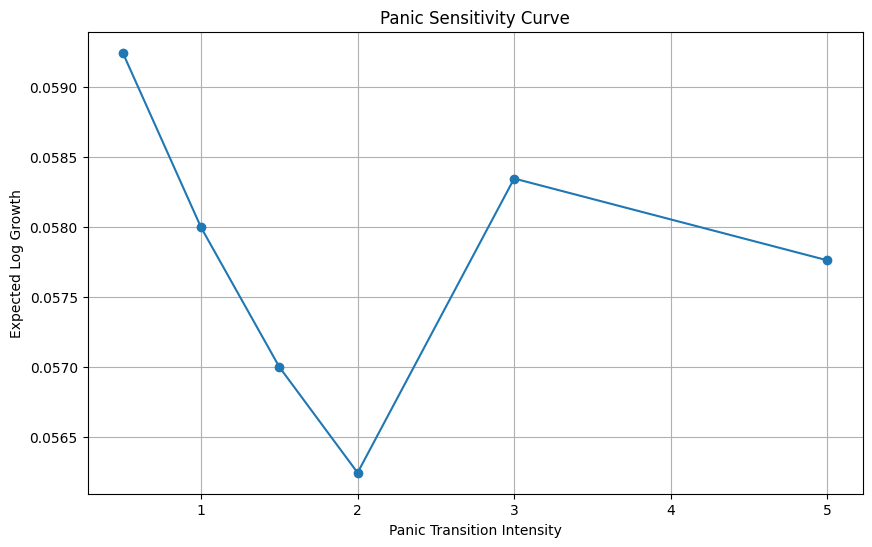

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(

    df["panic_scale"],

    df["mean_log_growth"],

    marker="o"
)

plt.xlabel("Panic Transition Intensity")

plt.ylabel("Expected Log Growth")

plt.title("Panic Sensitivity Curve")

plt.grid(True)

plt.show()

In [13]:
# --------------------------------------------------
# Project path setup
# --------------------------------------------------

import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [14]:
from src.research import (
    evaluate_policy,
    compare_policies
)

from src.portfolio.allocation_policies import (

    CarryMaximizerPolicy,

    RegimeAdaptivePolicy,

    RobustGrowthPolicy
)

In [15]:
policies = {

    "CarryMaximizer":
        CarryMaximizerPolicy(),

    "RegimeAdaptive":
        RegimeAdaptivePolicy(),

    "RobustGrowth":
        RobustGrowthPolicy(),
}

In [ ]:
comparison = compare_policies(

    policies=policies,

    transition_matrix=base_transition_matrix,

    n_paths=500,

    horizon=356
)

print(comparison)


c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


                mean_terminal_wealth  median_terminal_wealth  mean_cagr  \
policy                                                                    
CarryMaximizer          10588.671601            10703.217112   0.028231   
RegimeAdaptive          10582.914482            10628.402960   0.028597   
RobustGrowth            10597.358486            10646.209067   0.029303   

                median_cagr  mean_log_growth  mean_volatility  mean_drawdown  \
policy                                                                         
CarryMaximizer     0.034564         0.053947              NaN      -0.010697   
RegimeAdaptive     0.030941         0.056115              NaN      -0.003270   
RobustGrowth       0.031805         0.057500              NaN      -0.003468   

                worst_drawdown  mean_time_under_water  mean_VaR_5  \
policy                                                              
CarryMaximizer       -0.401247                  0.040    0.058867   
RegimeAdaptive  

In [17]:
panic_scales = [

    0.5,

    1.0,

    1.5,

    2.0,

    3.0,

    5.0
]

In [ ]:
results = []

for scale in panic_scales:

    perturbed_matrix = (
        perturb_panic_probability(
            base_transition_matrix,
            scale
        )
    )

    metrics = evaluate_policy(

        policy=RobustGrowthPolicy(),

        transition_matrix=perturbed_matrix,

        n_paths=500,

        horizon=356
    )

    metrics["panic_scale"] = scale

    results.append(metrics)

c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\ce81g\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [20]:
df = pd.DataFrame(results)